In [1]:
import os
import numpy as np
from PIL import Image
from typing import List, Tuple, Optional, Union
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:



def _np_dtype_from_nrrd_type(nrrd_type: str) -> np.dtype:
    """
    Map NRRD 'type' strings to NumPy dtypes.
    """
    mapping = {
        'uchar': np.uint8,
        'uint8': np.uint8,
        'short': np.int16,
        'ushort': np.uint16,
        'int': np.int32,
        'uint': np.uint32,
        'float': np.float32,
        'double': np.float64,
    }
    try:
        return mapping[nrrd_type]
    except KeyError:
        raise ValueError(f"Unsupported NRRD data type: {nrrd_type}")

class NRRDLoader:
    """
    Class for loading NRRD (.nhdr + .raw) volumetric data,
    extracting 2D slices, converting to images, sampling random crops,
    and compositing first N slices with optical dimming.
    """
    def __init__(self, header_path: str) -> None:
        self.header_path: str = header_path
        self.header: dict = {}
        self.sizes: Tuple[int, int, int]
        self.type: str
        self.endian: str
        self.encoding: str
        self.data_file: str
        self.data: Optional[np.ndarray] = None
        self._parse_header()

    def _parse_header(self) -> None:
        with open(self.header_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith(('#', 'NRRD')):
                    continue
                key, val = line.split(':', 1)
                self.header[key.strip()] = val.strip().strip('"')
        self.sizes = tuple(map(int, self.header['sizes'].split()))  # X, Y, Z
        self.type = self.header['type']
        self.endian = self.header.get('endian', 'little')
        self.encoding = self.header.get('encoding', 'raw')
        raw_name = self.header.get('data file', '')
        self.data_file = os.path.join(os.path.dirname(self.header_path), raw_name)

    def load_volume(self) -> np.ndarray:
        dtype = _np_dtype_from_nrrd_type(self.type)
        total = int(np.prod(self.sizes))
        with open(self.data_file, 'rb') as f:
            flat = np.fromfile(f, dtype=dtype, count=total)
        volume = flat.reshape(self.sizes[::-1]).transpose(0, 1, 2)
        self.data = volume
        return volume

    def get_slices(self, axis: int = 0) -> List[np.ndarray]:
        if self.data is None:
            self.load_volume()
        assert self.data is not None
        return [np.take(self.data, i, axis=axis) for i in range(self.data.shape[axis])]

    def slice_to_image(self, slice_array: np.ndarray) -> Image.Image:
        arr = slice_array.astype(np.float32)
        arr -= arr.min()
        arr /= (arr.ptp() + 1e-8)
        arr *= 255.0
        return Image.fromarray(arr.astype(np.uint8), mode='L')

    def save_slices(self, out_dir: str, axis: int = 0, prefix: str = 'slice') -> None:
        os.makedirs(out_dir, exist_ok=True)
        for idx, sl in enumerate(self.get_slices(axis=axis)):
            img = self.slice_to_image(sl)
            img.save(os.path.join(out_dir, f"{prefix}_{idx:04d}.png"))

    def sample_crops(
        self,
        num_crops: int = 7500,
        crop_size: int = 64,
        axis: int = 0
    ) -> List[Image.Image]:
        if self.data is None:
            self.load_volume()
        assert self.data is not None
        Z, H, W = self.data.shape
        crops: List[Image.Image] = []
        rng = np.random.default_rng()
        for _ in range(num_crops):
            if axis == 0:
                z = int(rng.integers(0, Z))
                y = int(rng.integers(0, H - crop_size + 1))
                x = int(rng.integers(0, W - crop_size + 1))
                patch = self.data[z, y:y+crop_size, x:x+crop_size]
            elif axis == 1:
                y = int(rng.integers(0, H))
                z = int(rng.integers(0, Z - crop_size + 1))
                x = int(rng.integers(0, W - crop_size + 1))
                patch = self.data[z:z+crop_size, y, x:x+crop_size]
            else:
                x = int(rng.integers(0, W))
                y = int(rng.integers(0, H - crop_size + 1))
                z = int(rng.integers(0, Z - crop_size + 1))
                patch = self.data[z:z+crop_size, y:y+crop_size, x]
            crops.append(self.slice_to_image(patch))
        return crops

    def plot_slice(
        self,
        slice_data: Union[np.ndarray, Image.Image],
        title: Optional[str] = None
    ) -> None:
        if isinstance(slice_data, Image.Image):
            arr = np.array(slice_data)
        else:
            arr = slice_data
        fig, ax = plt.subplots()
        ax.imshow(arr, cmap='gray')
        ax.axis('off')
        if title:
            ax.set_title(title)
        plt.show()
        

    def composite_slice(
        self,
        n: int = 5,
        axis: int = 0,
        decay: float = 0.6
    ) -> Image.Image:
        """
        Composite the first N slices along an axis with exponential dimming.

        Args:
            n: Number of front‐most slices to composite.
            axis: Axis along which to take slices (0=Z,1=Y,2=X).
            decay: Exponential decay factor for opacity per layer (0<decay<1).

        Returns:
            PIL Image of the composited "thick" slice.
        """
        slices = self.get_slices(axis=axis)[:n]
        # Normalize each slice to [0,1]
        normed = [(s.astype(np.float32) - s.min()) / (s.ptp() + 1e-8) for s in slices]
        composite = np.zeros_like(normed[0])
        weight = 1.0
        total_weight = 0.0
        for s in normed:
            composite += s * weight
            total_weight += weight
            weight *= decay
        composite /= total_weight
        # scale to [0,255]
        composite_img = (composite * 255.0).astype(np.uint8)
        return Image.fromarray(composite_img, mode='L')

    def save_composite(
        self,
        out_path: str,
        n: int = 5,
        axis: int = 0,
        decay: float = 0.6
    ) -> None:
        """
        Generate and save a composited slice to disk.

        Args:
            out_path: File path to save PNG.
            n: Number of slices to composite.
            axis: Axis along which to take slices.
            decay: Exponential decay per layer.
        """
        img = self.composite_slice(n=n, axis=axis, decay=decay)
        img.save(out_path)
        
    def save_images(self, out_path: str, images: List[Image.Image], ext: str = "png") -> None:
        
        for j, img in enumerate(images):
            img.save(out_path / f"crop_{j}.{ext}")

# Example usage:
# loader = NRRDLoader('A1.nhdr')
# loader.save_composite('composite.png', n=5, axis=0)


In [3]:
filename = "A1"
dataset_path = Path(r"C:\TopoGAN-ECCV2020\Data\rock")
nhdr_file = dataset_path / "data" / f"{filename}.nhdr"
slices_path = dataset_path / "comp_slices"

loader = NRRDLoader(nhdr_file)
loader.save_composite(slices_path / "composite.png", n=5, axis=0)

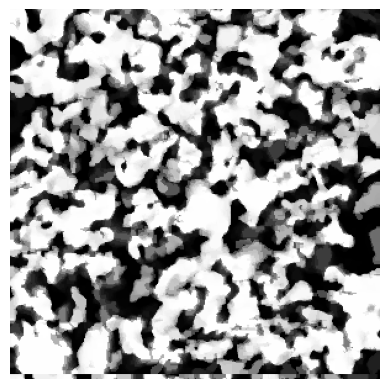

In [4]:
num_layers = 50

img = loader.composite_slice(n=num_layers, axis=0, decay=0.7)
loader.plot_slice(img)

In [5]:

filename = "A1"
dataset_path = Path(r"C:\TopoGAN-ECCV2020\Data\rock")
nhdr_file = dataset_path / "data" / f"{filename}.nhdr"
slices_path = dataset_path / "slices"
crops_path = dataset_path / "64x64"

loader = NRRDLoader(nhdr_file)
volume = loader.load_volume()
slices = loader.save_slices(slices_path, axis=0)
crops = loader.sample_crops(num_crops=7500, crop_size=64)


In [6]:
len(crops), type(crops[0])

(7500, PIL.Image.Image)

In [7]:
loader.save_images(crops_path, crops)

In [ ]:
# crops_128 = loader.sample_crops(num_crops=5, crop_size=128)
# loader.plot(crops_128)